# Lab 8 – Model Selection, Validation & Hyperparameter Tuning

30 min tutorial + 60 min exercises (you work!)

---

### What you will learn
| Technique | Question it answers |
|---|---|
| **Validation Curve** | What is the best value for *one* hyperparameter? |
| **Grid Search** | What is the best *combination* of hyperparameters? |
| **Learning Curve** | Do we need more data to improve the model? |

### Key concept: Why do we need a Validation Set?

When we tune hyperparameters we cannot use the **test set** — that would give us an optimistic estimate.  
Instead we hold out a **validation set** (or use **cross-validation**).

```
Full Dataset
├── Test set  (30%)  ← locked away, used ONLY at the very end
└── Train+Val (70%)
        ├── fold 1  ← validation
        ├── fold 2  ← validation  (k-fold cross-validation rotates the folds)
        └── fold 3  ← validation
```

---
## PART 1 – Tutorial 

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print('Libraries loaded!')

Libraries loaded!


### T1 – Load the Iris dataset and prepare it

We split **once** into train+val (70%) and test (30%).  
The test set is **never touched** during tuning.

In [ ]:
# Load Iris (3 classes, 4 features, 150 samples)
iris = load_iris()
X, y = iris.data, iris.target

print(f'Samples  : {X.shape[0]}')
print(f'Features : {X.shape[1]}')
print(f'Classes  : {np.unique(y)}  → {list(iris.target_names)}')

Samples  : 150
Features : 4
Classes  : [0 1 2]  → [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Train+Val: 105 samples
Test     : 45 samples


In [3]:
# 1. Train+val / test split  (stratified = same class proportions in both sets)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, train_size=0.70, stratify=y, random_state=42
)

# 2. Standardise: fit ONLY on train+val, then apply to both
scaler = StandardScaler()
X_tv   = scaler.fit_transform(X_tv)
X_test = scaler.transform(X_test)

print(f'\nTrain+Val: {X_tv.shape[0]} samples')
print(f'Test     : {X_test.shape[0]} samples')


Train+Val: 105 samples
Test     : 45 samples


###  What is Cross Validation?

- Divide your dataset into k partitions
- At each iteration select a partition to be used as test set and the others will be the training set

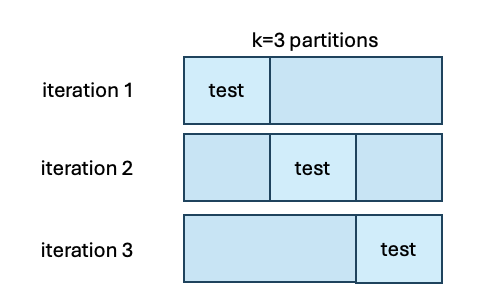

- At the end you can compute statistics on the obtained scores

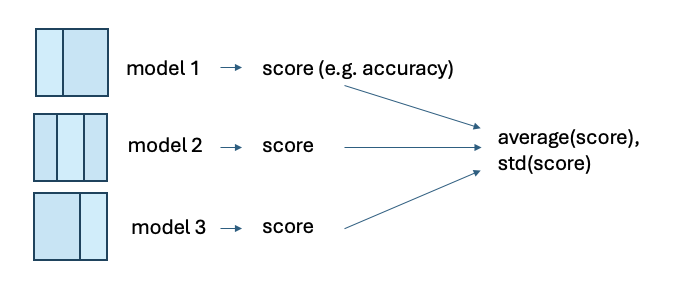





### T2 – Validation Curve

We vary **one hyperparameter** (`max_depth`) and measure train vs. validation accuracy.  
For each value we use **5-fold cross-validation** to get a reliable estimate.

The band around each curve shows the **min–max range** across the 5 folds.

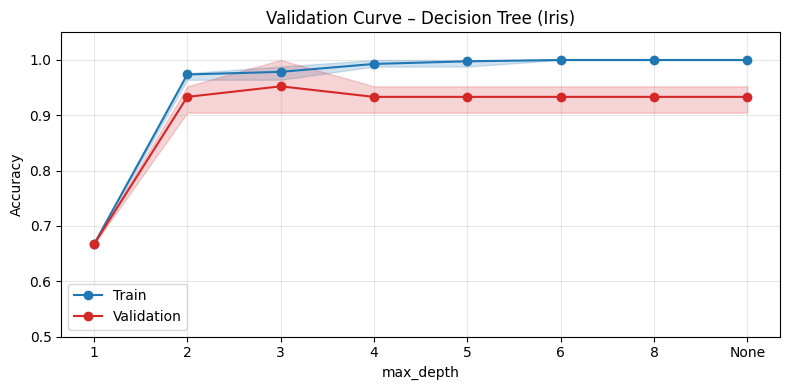

Best max_depth: 3  (val acc = 0.952)


In [4]:
# ── Tutorial: Validation Curve for max_depth ────────────────────────────────
depth_values = [1, 2, 3, 4, 5, 6, 8, None]

tr_mean, tr_min, tr_max = [], [], []
vl_mean, vl_min, vl_max = [], [], []

for depth in depth_values:

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    acc_tr, acc_vl = [], []

    for tr_idx, vl_idx in cv.split(X_tv, y_tv):
        model = DecisionTreeClassifier(max_depth=depth, random_state=0)
        model.fit(X_tv[tr_idx], y_tv[tr_idx])
        acc_tr.append(accuracy_score(y_tv[tr_idx], model.predict(X_tv[tr_idx])))
        acc_vl.append(accuracy_score(y_tv[vl_idx], model.predict(X_tv[vl_idx])))

    tr_mean.append(np.mean(acc_tr)); tr_min.append(np.min(acc_tr)); tr_max.append(np.max(acc_tr))
    vl_mean.append(np.mean(acc_vl)); vl_min.append(np.min(acc_vl)); vl_max.append(np.max(acc_vl))

# ── Plot ────────────────────────────────────────────────────────────────────
x_lbl = [str(d) for d in depth_values]
xp    = range(len(depth_values))

plt.figure(figsize=(8, 4))
plt.plot(xp, tr_mean, 'o-', color='tab:blue',  label='Train')
plt.fill_between(xp, tr_min, tr_max, alpha=0.2, color='tab:blue')
plt.plot(xp, vl_mean, 'o-', color='tab:red', label='Validation')
plt.fill_between(xp, vl_min, vl_max, alpha=0.2, color='tab:red')
plt.xticks(xp, x_lbl)
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Validation Curve – Decision Tree (Iris)')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0.5, 1.05)
plt.tight_layout(); plt.show()

best_i = int(np.argmax(vl_mean))
print(f'Best max_depth: {depth_values[best_i]}  (val acc = {vl_mean[best_i]:.3f})')

### T3 – Grid Search

Grid Search **exhaustively** tests every combination from a parameter grid.  
Think of it as a table where each cell = one model configuration.

In [6]:
# ── Tutorial: Grid Search ────────────────────────────────────────────────────
param_grid = {
    'max_depth' : [2, 3, 4, 5],
    'criterion' : ['gini', 'entropy'],
}

results = []

for depth in param_grid['max_depth']:
    for crit in param_grid['criterion']:

        cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        acc_vl = []
        for tr_idx, vl_idx in cv.split(X_tv, y_tv):
            m = DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=0)
            m.fit(X_tv[tr_idx], y_tv[tr_idx])
            acc_vl.append(accuracy_score(y_tv[vl_idx], m.predict(X_tv[vl_idx])))

        results.append({'max_depth': depth, 'criterion': crit,
                        'val_acc': np.mean(acc_vl)})

results.sort(key=lambda r: r['val_acc'], reverse=True)

print(f'{"max_depth":>12} {"criterion":>10} {"val_acc":>10}')
print('-' * 35)
for r in results:
    print(f"{r['max_depth']:>12}  {r['criterion']:>10}  {r['val_acc']:>10.3f}")

best_tutorial = results[0]
print(f"\nBest: {best_tutorial}")

   max_depth  criterion    val_acc
-----------------------------------
           3        gini       0.952
           3     entropy       0.952
           2        gini       0.933
           2     entropy       0.933
           4        gini       0.933
           4     entropy       0.933
           5        gini       0.933
           5     entropy       0.933

Best: {'max_depth': 3, 'criterion': 'gini', 'val_acc': np.float64(0.9523809523809523)}


### T4 – Learning Curve

We train the best model on **increasing fractions** of the training data.  
If the validation curve is still rising → more data would help.  
If it has plateaued → collecting more data is unlikely to help.

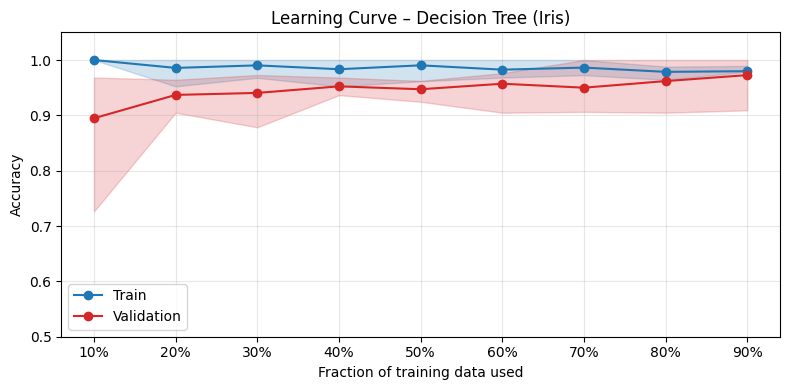

In [7]:
# ── Tutorial: Learning Curve ─────────────────────────────────────────────────
train_sizes = np.arange(0.10, 1.00, 0.10)

lc_tr_mean, lc_tr_min, lc_tr_max = [], [], []
lc_vl_mean, lc_vl_min, lc_vl_max = [], [], []

for size in train_sizes:
    acc_tr_rep, acc_vl_rep = [], []

    for rep in range(10):   # 10 random splits per size
        sss = StratifiedShuffleSplit(n_splits=1, train_size=size, random_state=rep)
        tr_i, vl_i = next(sss.split(X_tv, y_tv))

        m = DecisionTreeClassifier(
            max_depth=best_tutorial['max_depth'],
            criterion=best_tutorial['criterion'],
            random_state=0)
        m.fit(X_tv[tr_i], y_tv[tr_i])
        acc_tr_rep.append(accuracy_score(y_tv[tr_i], m.predict(X_tv[tr_i])))
        acc_vl_rep.append(accuracy_score(y_tv[vl_i], m.predict(X_tv[vl_i])))

    lc_tr_mean.append(np.mean(acc_tr_rep)); lc_tr_min.append(np.min(acc_tr_rep)); lc_tr_max.append(np.max(acc_tr_rep))
    lc_vl_mean.append(np.mean(acc_vl_rep)); lc_vl_min.append(np.min(acc_vl_rep)); lc_vl_max.append(np.max(acc_vl_rep))

# ── Plot ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_sizes, lc_tr_mean, 'o-', color='tab:blue',  label='Train')
plt.fill_between(train_sizes, lc_tr_min, lc_tr_max, alpha=0.2, color='tab:blue')
plt.plot(train_sizes, lc_vl_mean, 'o-', color='tab:red', label='Validation')
plt.fill_between(train_sizes, lc_vl_min, lc_vl_max, alpha=0.2, color='tab:red')
plt.xticks(train_sizes, [f'{s:.0%}' for s in train_sizes])
plt.xlabel('Fraction of training data used'); plt.ylabel('Accuracy')
plt.title('Learning Curve – Decision Tree (Iris)')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0.5, 1.05)
plt.tight_layout(); plt.show()

---
---
## ⏱ PART 2 – Lab Exercises  *(you work!)*

You will now apply the same three techniques on the **Wine** dataset.  
Complete every cell that contains `# TODO`.

> **Tip**: look at the tutorial cells above — the structure is exactly the same!

---
### Dataset: Wine
- **178 samples**, **13 chemical features**, **3 wine classes**
- Goal: classify wines based on their chemical analysis

---
### Exercise 0 – Load & Prepare the Wine Dataset 

In [8]:
# ── Exercise 0: Load and split the Wine dataset ──────────────────────────────

wine = load_wine()
X_w, y_w = wine.data, wine.target

print(f'Samples  : {X_w.shape[0]}')
print(f'Features : {X_w.shape[1]}')
print(f'Classes  : {np.unique(y_w)}  → {list(wine.target_names)}')

# TODO 0a: Split into train+val (70%) and test (30%).
#           Use stratify=y_w and random_state=42
#           Name the variables:  X_w_tv, X_w_test, y_w_tv, y_w_test

# --- your code here ---


# TODO 0b: Standardise the data.
#          Create a StandardScaler, fit on X_w_tv, transform both sets.
#          Overwrite:  X_w_tv, X_w_test

# --- your code here ---


# Check (uncomment after completing)
# print(f'Train+Val: {X_w_tv.shape[0]} samples')
# print(f'Test     : {X_w_test.shape[0]} samples')

Samples  : 178
Features : 13
Classes  : [0 1 2]  → [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


---
### Exercise 1 – Validation Curve for k-NN  

We will vary the hyperparameter **`n_neighbors`** of a k-Nearest Neighbours classifier.  
For each value, use **5-fold cross-validation** (same as in the tutorial).  
Save the mean, min and max accuracy across the 5 folds for both train and validation sets.

Values to test: `[1, 3, 5, 7, 9, 11, 15, 21]`

In [ ]:
# ── Exercise 1: Validation Curve – k-NN ─────────────────────────────────────

k_values = [1, 3, 5, 7, 9, 11, 15, 21]

tr_mean_knn, tr_min_knn, tr_max_knn = [], [], []
vl_mean_knn, vl_min_knn, vl_max_knn = [], [], []

# TODO 1a: Loop over each value in k_values.
#          For each k, run 5-fold cross-validation using StratifiedShuffleSplit
#          (n_splits=5, test_size=0.2, random_state=0).
#          Inside the fold loop:
#            - Create a KNeighborsClassifier with n_neighbors=k
#            - Fit on the training fold
#            - Compute accuracy on BOTH train fold and validation fold
#          After each k, append mean/min/max to the lists above.

# --- your code here ---


# TODO 1b: Plot the validation curve.
#          - x-axis: k values
#          - y-axis: accuracy
#          - Two lines: train (blue) and validation (red)
#          - Shaded band between min and max
#          - Add labels, title, legend, grid

# --- your code here ---


# TODO 1c: Print the best value of k (highest mean validation accuracy)

# --- your code here ---

**Reflection questions – Exercise 1**

1. What happens to training accuracy when k=1? Why?
2. What happens to validation accuracy when k is very large?
3. What is the trade-off that the validation curve helps you find?

---
### Exercise 2 – Grid Search for Decision Tree

Search over the following hyperparameter grid for a `DecisionTreeClassifier`:

| Hyperparameter | Values to test |
|---|---|
| `max_depth` | 2, 3, 4, 5, `None` |
| `criterion` | `'gini'`, `'entropy'` |
| `min_samples_split` | 2, 5, 10 |

Use 5-fold cross-validation for each combination.

In [ ]:
# ── Exercise 2: Grid Search – Decision Tree ──────────────────────────────────

param_grid_ex = {
    'max_depth'         : [2, 3, 4, 5, None],
    'criterion'         : ['gini', 'entropy'],
    'min_samples_split' : [2, 5, 10],
}

gs_results = []   # each entry: dict with params + val_acc_mean

# TODO 2a: Write three nested loops over max_depth, criterion, min_samples_split.
#          For each combination:
#            - Run 5-fold CV (StratifiedShuffleSplit, n_splits=5, test_size=0.2, random_state=0)
#            - Train a DecisionTreeClassifier with the current params (random_state=0)
#            - Compute mean validation accuracy across the 5 folds
#            - Append a dict to gs_results:
#              {'max_depth': ..., 'criterion': ..., 'min_samples_split': ..., 'val_acc': ...}

# --- your code here ---


# TODO 2b: Sort gs_results by val_acc descending and print the top 5.

# --- your code here ---


# TODO 2c: Store the best configuration in a variable called `best_params`.
#          Print it.

# --- your code here ---

In [ ]:
# ── Exercise 2d: Visualise Grid Search results ───────────────────────────────

# TODO 2d: Create a bar chart showing the validation accuracy for every
#          combination (x-axis = configuration index, y-axis = val_acc).
#          Highlight the best bar in a different colour.
#          Add labels, title, and a legend.
#
#  Hint: use the gs_results list after sorting it.

# --- your code here ---

**Reflection questions – Exercise 2**

1. How many total combinations did the grid search evaluate?  
   *(count manually: 5 × 2 × 3 = ?)*
2. Which hyperparameter seems to have the largest effect on performance?
3. What is a disadvantage of Grid Search when the grid is very large?

---
### Exercise 3 – Learning Curve 

Use the best hyperparameters found in Exercise 2.  
Train the model on increasing fractions of the training data: **10 %, 20 %, … 90 %**.  
For each fraction, repeat the experiment **10 times** with different random seeds  
to get stable statistics.

In [ ]:
# ── Exercise 3: Learning Curve ───────────────────────────────────────────────

train_fracs = np.arange(0.10, 1.00, 0.10)

lc_tr_mean_ex, lc_tr_min_ex, lc_tr_max_ex = [], [], []
lc_vl_mean_ex, lc_vl_min_ex, lc_vl_max_ex = [], [], []

# TODO 3a: Loop over each fraction in train_fracs.
#          For each fraction, repeat 10 times (random_state = rep, rep in range(10)):
#            - Use StratifiedShuffleSplit(n_splits=1, train_size=fraction, random_state=rep)
#            - Train a DecisionTreeClassifier with best_params (random_state=0)
#            - Record train and validation accuracy for each repetition
#          After 10 repetitions, append mean/min/max to the lists above.
#
#  Hint: use best_params['max_depth'], best_params['criterion'],
#        best_params['min_samples_split']

# --- your code here ---


# TODO 3b: Plot the learning curve.
#          - x-axis: fraction of training data (format as percentage)
#          - y-axis: accuracy
#          - Two lines (train / validation) with shaded min-max bands
#          - Add labels, title, legend, grid

# --- your code here ---

**Reflection questions – Exercise 3**

1. At what fraction does the validation curve start to plateau?
2. Would collecting more data likely improve this model? Justify your answer.
3. Why does the shaded band (min–max) become narrower as we use more data?

---
### Exercise 4 – Final Evaluation on the Test Set

Now — and **only now** — we look at the test set.  
Train the final model on the **entire** train+val set with the best hyperparameters.

In [ ]:
# ── Exercise 4: Final model on the test set ───────────────────────────────────

# TODO 4a: Create a DecisionTreeClassifier with best_params and random_state=0.
#          Fit it on the FULL train+val set (X_w_tv, y_w_tv).

# --- your code here ---


# TODO 4b: Predict on X_w_test and compute the accuracy.
#          Print the best hyperparameters and the test accuracy.

# --- your code here ---


# TODO 4c: Print the full classification_report (precision, recall, f1-score).
#          Use target_names=wine.target_names for readable class names.

# --- your code here ---

In [ ]:
# ── Exercise 4d: Confusion Matrix ────────────────────────────────────────────

# TODO 4d: Compute the confusion matrix and visualise it as a heatmap with seaborn.
#          Use annot=True, fmt='d', cmap='Blues'.
#          Label the axes with the class names from wine.target_names.

# --- your code here ---

**Reflection questions – Exercise 4**

1. Which class is hardest to classify? How can you tell from the confusion matrix?
2. Is the test accuracy close to the validation accuracy you saw in the Grid Search?  
   What does it mean if they are very different?
3. Why is it important to look at precision and recall, not just accuracy?

---
## Summary

```
Full Dataset
  ├── Test set (30%)  ← used ONLY in Exercise 4
  └── Train+Val (70%)
          ├── Ex 1: Validation Curve  → best k for k-NN
          ├── Ex 2: Grid Search       → best combo for Decision Tree
          └── Ex 3: Learning Curve    → how much data is enough?
```

| Technique | Key idea | What to look for |
|---|---|---|
| **Validation Curve** | Vary one hyperparameter | Where validation accuracy peaks |
| **Grid Search** | Try all combinations | Combination with highest val accuracy |
| **Learning Curve** | Vary training set size | Does val accuracy still rise? |

### Overfitting vs Underfitting — quick reminder

| Symptom | Likely cause | Fix |
|---|---|---|
| Train ↑, Val ↓ | **Overfitting** | Reduce complexity (smaller depth, larger k, …) |
| Train ↓, Val ↓ | **Underfitting** | Increase complexity or get better features |
| Val still rising with more data | Need more data | Collect more samples |
| Val plateau with more data | Data is not the bottleneck | Improve model or features |